In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\csv files\training (1).csv")

In [3]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [5]:
df["FraudResult"].value_counts() #it is inbalanced

FraudResult
0    95469
1      193
Name: count, dtype: int64

In [6]:
df.isna().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

## Feature Engineering

engineering new features to the data

In [9]:
df["Month"] = df["TransactionStartTime"].dt.month

In [10]:
df["Day"] = df["TransactionStartTime"].dt.day

In [11]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Month,Day
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,11,15
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,11,15
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,11,15
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,11,15
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,11,15


In [12]:
def credit_or_debit(row):
    if row < 0:
        return 0 #represent credit
    else:
        return 1 #represent debit

In [13]:
df["Credit_or_Debit"] = df["Amount"].apply(credit_or_debit)

In [14]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Month,Day,Credit_or_Debit
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,11,15,1
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,11,15,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,11,15,1
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,11,15,1
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,11,15,0


In [15]:
df["CurrencyCode"].value_counts()

CurrencyCode
UGX    95662
Name: count, dtype: int64

In [16]:
X = df.drop(columns = ["TransactionId", "CurrencyCode", "CountryCode", "Amount", "TransactionStartTime", "FraudResult"])

In [17]:
X.head()

,BatchId,AccountId,SubscriptionId,CustomerId,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,Month,Day,Credit_or_Debit
0,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000,2,11,15,1
1,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,ProviderId_4,ProductId_6,financial_services,ChannelId_2,20,2,11,15,0
2,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,ProviderId_6,ProductId_1,airtime,ChannelId_3,500,2,11,15,1
3,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,21800,2,11,15,1
4,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,ProviderId_4,ProductId_6,financial_services,ChannelId_2,644,2,11,15,0


In [18]:
X.shape

(95662, 13)

In [19]:
y = df["FraudResult"]

## Feature Encoding

In [20]:
categorical_col = X.select_dtypes(include = ["object"]).columns.tolist()

categorical_col

['BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId']

In [21]:
le = LabelEncoder()

for col in categorical_col:
    X[col] = le.fit_transform(X[col])

In [22]:
X.head()

,BatchId,AccountId,SubscriptionId,CustomerId,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,Month,Day,Credit_or_Debit
0,46980,2490,3535,2584,5,1,0,2,1000,2,11,15,1
1,31755,3219,2366,2584,3,19,2,1,20,2,11,15,0
2,60272,2713,996,2806,5,0,0,2,500,2,11,15,1
3,1797,3351,974,3733,0,11,8,2,21800,2,11,15,1
4,48941,3219,2366,3733,3,19,2,1,644,2,11,15,0


## Feature Correlation
check how correlated your features are

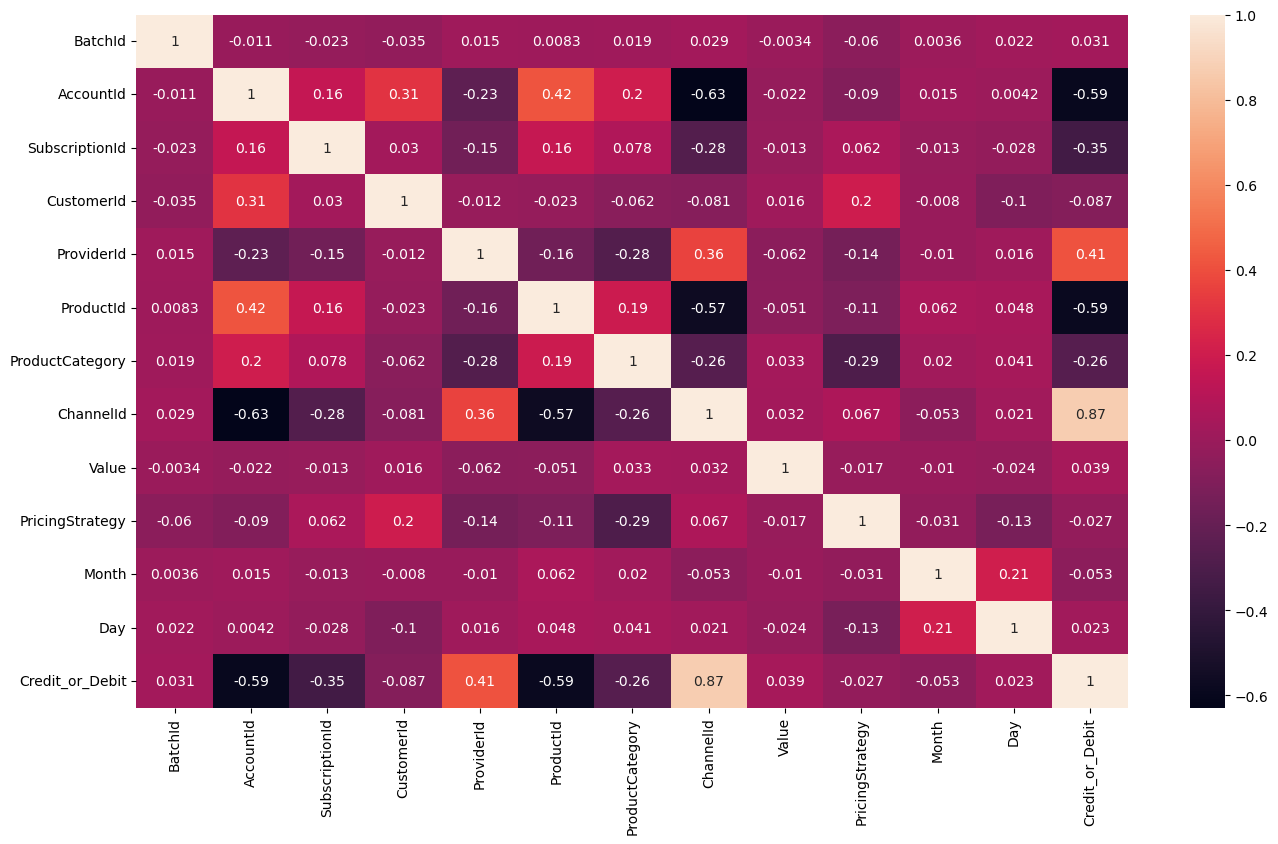

In [23]:
plt.figure(figsize = (16, 9))
sns.heatmap(X.corr(), annot = True)
plt.show()

## Feature Scaling

In [24]:
scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [25]:
scaledX

array([[-0.01556319,  0.1537132 ,  1.6686459 , ...,  0.84868424,
        -0.10073863,  0.81514939],
       [-0.57173322,  0.86719027,  0.34644914, ...,  0.84868424,
        -0.10073863, -1.22676899],
       [ 0.46999424,  0.37196476, -1.20308855, ...,  0.84868424,
        -0.10073863,  0.81514939],
       ...,
       [-1.22430605,  0.86719027,  0.34644914, ..., -0.87404014,
        -0.32388379, -1.22676899],
       [ 0.93546015, -1.99356897,  1.45261547, ..., -0.87404014,
        -0.32388379,  0.81514939],
       [-0.19708102,  0.86719027,  0.34644914, ..., -0.87404014,
        -0.32388379, -1.22676899]])

In [26]:
y.value_counts() #classes are imbalanced 50 : 50

FraudResult
0    95469
1      193
Name: count, dtype: int64

## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size = 0.2, random_state = 32)

## Training

In [28]:
log = LogisticRegression()

log.fit(X_train, y_train)

LogisticRegression()

In [29]:
log_pred = log.predict(X_test)

In [30]:
#accuracy score ranges from 0 to 1

accuracy_score(y_test, log_pred)

0.9979093712434014

In [31]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19098
           1       0.35      0.17      0.23        35

    accuracy                           1.00     19133
   macro avg       0.68      0.59      0.61     19133
weighted avg       1.00      1.00      1.00     19133



accuracy is the percentage of total predictiont the model got right

accuracy = correct prediction/total predictions

In [32]:
cm = confusion_matrix(y_test, log_pred)
cm

array([[19087,    11],
       [   29,     6]])

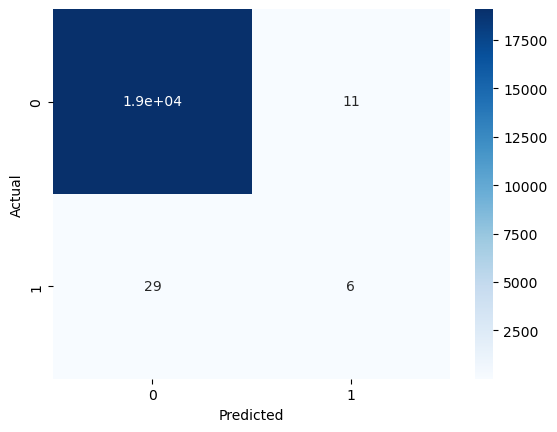

In [33]:
sns.heatmap(cm, annot = True, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- True Negative - 19087 (the number of non - fraudulent transactions the model rightly predicted)
- False Positive - 11 (the number of non - fraudulent transactions the model predicted as fraudulent)
- True Positive - 6 (the number of fraudulent transactions the model predicted rightly)
- False Negative - 29 (the number of fraudulent transactions the model predicted as non-fraudulent

Precision = Truepositive/(Truepositive + Falsepositive)

of all transaction predicted as fraud, how many are actually fraud

In [34]:
6/(6+11)

0.35294117647058826

Recall = TP/(TP + FN)

of all transaction, how many did the model catch

In [35]:
6/(6+29)

0.17142857142857143

F1-Score

Harmonic mean of precision and recall

this is the best metric for imbalanced test

classification is used to predict only classes(discrete) like is it fraudulent or not, not continous like price of houses

In [36]:
boost = XGBClassifier(random_state = 6)

boost.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=6, ...)

In [37]:
boost_pred = boost.predict(X_test)

In [38]:
print(classification_report(y_test, boost_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19098
           1       0.50      0.51      0.51        35

    accuracy                           1.00     19133
   macro avg       0.75      0.76      0.75     19133
weighted avg       1.00      1.00      1.00     19133



In [39]:
accuracy_score(y_test, boost_pred)

0.9981706998379762

In [40]:
forest = RandomForestClassifier(random_state = 10)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=10)

In [41]:
forest_preds = forest.predict(X_test)

In [42]:
print(classification_report(y_test, forest_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19098
           1       0.86      0.69      0.76        35

    accuracy                           1.00     19133
   macro avg       0.93      0.84      0.88     19133
weighted avg       1.00      1.00      1.00     19133



In [43]:
#Grid Search

#Random Search

## ROC Curve

receiver operating characteristic curve

- it shows the relationship btw false positive rate and true positive rate

In [44]:
forest_prob = forest.predict_proba(X_test)[:,1]

forest_prob

array([0., 0., 0., ..., 0., 0., 0.])

In [45]:
#area under the roc curve
auc_score = roc_auc_score(y_test, forest_prob)

auc_score

np.float64(0.9279490746974253)

if auc score = 1, then the classifier is perfect

if auc score = 0.5, the classifier is guessing

if auc score < 0.5, the classifier is bad

In [46]:
fpr, tpr, threshold = roc_curve(y_test, forest_prob)

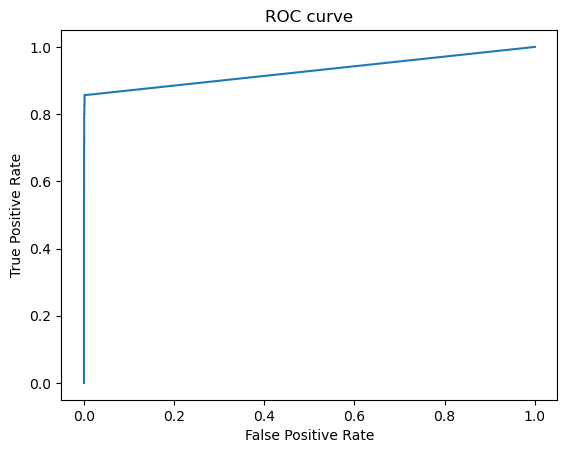

In [47]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.show()

## Feature Importance

In [48]:
importances = forest.feature_importances_ #pick the best model that did well

importances

array([5.38024049e-02, 4.15193840e-02, 3.17929415e-02, 4.30160337e-02,
       1.78373971e-02, 9.79620263e-03, 5.84994107e-03, 1.40617545e-03,
       7.28229579e-01, 1.32687040e-02, 1.28963414e-02, 4.00242986e-02,
       5.60596660e-04])

In [49]:
X.columns

Index(['BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'ProviderId',
       'ProductId', 'ProductCategory', 'ChannelId', 'Value', 'PricingStrategy',
       'Month', 'Day', 'Credit_or_Debit'],
      dtype='object')

In [84]:
df['ChannelId'].unique().tolist()

['ChannelId_3', 'ChannelId_2', 'ChannelId_1', 'ChannelId_5']

In [54]:
importance_df = pd.DataFrame({"Feature":X.columns, "Importance":importances}).sort_values(by = "Importance", ascending = False)

importance_df

,Feature,Importance
8,Value,0.728230
0,BatchId,0.053802
3,CustomerId,0.043016
1,AccountId,0.041519
11,Day,0.040024
2,SubscriptionId,0.031793
4,ProviderId,0.017837
9,PricingStrategy,0.013269
10,Month,0.012896
5,ProductId,0.009796


In [51]:
import pickle

#model
with open("fraud_model.pkl", "wb") as file:
    pickle.dump(forest, file)

In [52]:
#encoder
with open("fraud_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

#scaler
with open("fraud_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [53]:
X.columns

Index(['BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'ProviderId',
       'ProductId', 'ProductCategory', 'ChannelId', 'Value', 'PricingStrategy',
       'Month', 'Day', 'Credit_or_Debit'],
      dtype='object')